In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
pipeline = joblib.load(
    "../models/xgboost_prediction_pipeline.pkl"
)

model = pipeline["model"]
features = pipeline["features"]

print("Model loaded successfully!")
print("Number of features:", len(features))

Model loaded successfully!
Number of features: 34


In [3]:
feature_importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
27,d_1906,0.201447
33,d_1912,0.175773
13,d_1892,0.120835
11,d_1890,0.048126
29,d_1908,0.033906
19,d_1898,0.030581
20,d_1899,0.028007
28,d_1907,0.027701
30,d_1909,0.025301
31,d_1910,0.023352


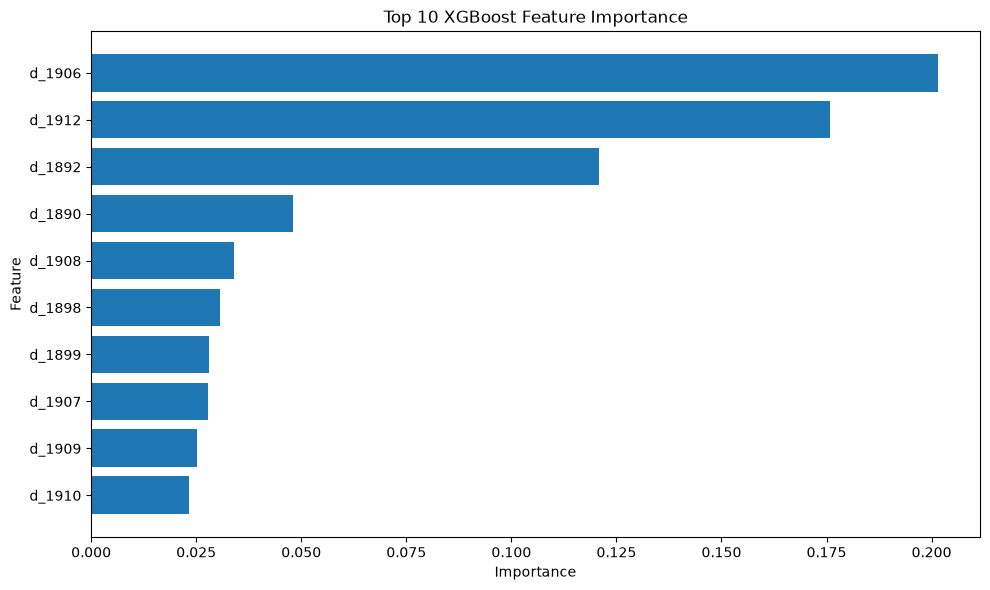

In [4]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [5]:
feature_importance_df.to_csv(
    "../data/processed/xgboost_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [6]:
feature_importance_check = pd.read_csv(
    "../data/processed/xgboost_feature_importance.csv"
)

feature_importance_check.head(10)

,Feature,Importance
0,d_1906,0.201447
1,d_1912,0.175773
2,d_1892,0.120835
3,d_1890,0.048126
4,d_1908,0.033906
5,d_1898,0.030581
6,d_1899,0.028007
7,d_1907,0.027701
8,d_1909,0.025301
9,d_1910,0.023352


In [7]:
top_10_features = feature_importance_check.head(10)

top_10_features

,Feature,Importance
0,d_1906,0.201447
1,d_1912,0.175773
2,d_1892,0.120835
3,d_1890,0.048126
4,d_1908,0.033906
5,d_1898,0.030581
6,d_1899,0.028007
7,d_1907,0.027701
8,d_1909,0.025301
9,d_1910,0.023352


In [8]:
print("Explainable AI Summary")
print("-" * 30)

top_feature = top_10_features.iloc[0]

print(
    f"The most important feature is {top_feature['Feature']} "
    f"with an importance score of {top_feature['Importance']:.4f}."
)

print(
    "The feature importance values show which input features "
    "contribute most to the XGBoost model's predictions."
)

Explainable AI Summary
------------------------------
The most important feature is d_1906 with an importance score of 0.2014.
The feature importance values show which input features contribute most to the XGBoost model's predictions.


In [9]:
print("Phase 7 - Explainable AI completed successfully!")
print("Model: XGBoost")
print("Total Features:", len(features))
print("Top Feature:", top_10_features.iloc[0]["Feature"])
print("Top Feature Importance:", round(top_10_features.iloc[0]["Importance"], 4))

Phase 7 - Explainable AI completed successfully!
Model: XGBoost
Total Features: 34
Top Feature: d_1906
Top Feature Importance: 0.2014
